In [40]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
# 윈도우 기준 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("폰트 설정 완료!")

폰트 설정 완료!


In [41]:
from pathlib import Path


# 현재 작업 폴더 기준 (노트북이 있는 폴더)
DATA_PATH = Path("online_retail_II.xlsx")

df_2009 = pd.read_excel(DATA_PATH, sheet_name="Year 2009-2010")
df_2010 = pd.read_excel(DATA_PATH, sheet_name="Year 2010-2011")

print(df_2009.shape)
print(df_2009.head())

(525461, 8)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


### 전체 흐름 : 2009·2010 거래 데이터를 합친 뒤, 취소·반품을 제거하지 않고 순매출(Net Sales)에 반영할 수 있도록 정리

In [42]:
# 1. 합치기
df = pd.concat([df_2009, df_2010], ignore_index=True)
print(f"2009-2010 시트: {len(df_2009):,}행")
print(f"2010-2011 시트: {len(df_2010):,}행")
print(f"합친 후 전체: {len(df):,}행")

# 2. 날짜 범위 확인
print(f"\n날짜 범위:")
print(f"시작: {df['InvoiceDate'].min()}")
print(f"종료: {df['InvoiceDate'].max()}")

2009-2010 시트: 525,461행
2010-2011 시트: 541,910행
합친 후 전체: 1,067,371행

날짜 범위:
시작: 2009-12-01 07:45:00
종료: 2011-12-09 12:50:00


### 1. 결측/사분위수 진단 출력 → 타입 정규화 → 중복 제거.
astype(str)을 실행하면  df.isnull().sum()이 Invoice/StockCode에 대해 무조건 0을 출력하는 것을 방지<br>
duplicated()를 돌리면 동일한 거래가 서로 다른 값 (예 : 536365와 '536365')으로 잡혀서 중복이 과소 탐지되는 것을 방지

In [43]:
# 1. 숫자형 칼럼 기초통계와 결측치
numeric_desc = df.describe()
numeric_desc.loc['missing'] = (
    df.select_dtypes(include='number')
    .isnull()
    .sum()
)

print("\n숫자형 칼럼 기초통계:")
print(numeric_desc)

# 2. 칼럼별 자료형
print("\n칼럼별 자료형:")
print(df.dtypes)

# 3. 전체 칼럼별 결측치
print("\n칼럼별 결측치:")
print(df.isnull().sum())




숫자형 칼럼 기초통계:
             Quantity                    InvoiceDate         Price  \
count    1.067371e+06                        1067371  1.067371e+06   
mean     9.938898e+00  2011-01-02 21:13:55.394028544  4.649388e+00   
min     -8.099500e+04            2009-12-01 07:45:00 -5.359436e+04   
25%      1.000000e+00            2010-07-09 09:46:00  1.250000e+00   
50%      3.000000e+00            2010-12-07 15:28:00  2.100000e+00   
75%      1.000000e+01            2011-07-22 10:23:00  4.150000e+00   
max      8.099500e+04            2011-12-09 12:50:00  3.897000e+04   
std      1.727058e+02                            NaN  1.235531e+02   
missing  0.000000e+00                            NaN  0.000000e+00   

           Customer ID  
count    824364.000000  
mean      15324.638504  
min       12346.000000  
25%       13975.000000  
50%       15255.000000  
75%       16797.000000  
max       18287.000000  
std        1697.464450  
missing  243007.000000  

칼럼별 자료형:
Invoice                ob

In [44]:
# ============================================================
# 변환 전 데이터 보관
# ============================================================
before_df = df.copy()

In [45]:
# ============================================================
# 전체 거래 기본 전처리
# ============================================================
# Invoice 열의 값을 문자열 형태로 변환
df['Invoice'] = (
    df['Invoice']

    # 숫자형·문자형이 섞여 있어도 모두 문자열로 통일
    # 취소 송장번호처럼 C536379 형태의 값도 안전하게 처리 가능
    .astype(str)

    # 문자열 앞뒤의 불필요한 공백 제거
    # 예: ' 536365 ' → '536365'
    .str.strip()
)


# StockCode 열의 값을 문자열 형태로 변환
df['StockCode'] = (
    df['StockCode']
    # 상품 코드에는 숫자뿐 아니라 85123A, POST 같은 문자도 있으므로
    # 문자열로 통일
    .astype(str)
    # 상품 코드 앞뒤의 불필요한 공백 제거
    # 예: ' 85123A ' → '85123A'
    .str.strip()
)


# InvoiceDate 열을 날짜·시간 자료형으로 변환
df['InvoiceDate'] = pd.to_datetime(
    df['InvoiceDate'],
    # 날짜로 변환할 수 없는 값은 오류를 발생시키지 않고 날짜형 결측값인 NaT로 변환
    errors='coerce'
)


# Quantity 열을 숫자형으로 변환
df['Quantity'] = pd.to_numeric(
    df['Quantity'],

    # 숫자로 변환할 수 없는 값은 오류 대신 NaN으로 변환
    errors='coerce'
)

# Price 열을 숫자형으로 변환
df['Price'] = pd.to_numeric(
    df['Price'],
    errors='coerce'
)


In [46]:
# InvoiceDate 변환 실패
failed_date = df[
    before_df['InvoiceDate'].notna()
    & df['InvoiceDate'].isna()
]

print("\nInvoiceDate 변환 실패 행:")
print(
    failed_date[
        ['Invoice', 'InvoiceDate']
    ].head(20)
)


# Quantity 변환 실패
failed_quantity = df[
    before_df['Quantity'].notna()
    & df['Quantity'].isna()
]

print("\nQuantity 변환 실패 행:")
print(
    failed_quantity[
        ['Invoice', 'StockCode', 'Quantity']
    ].head(20)
)


# Price 변환 실패
failed_price = df[
    before_df['Price'].notna()
    & df['Price'].isna()
]

print("\nPrice 변환 실패 행:")
print(
    failed_price[
        ['Invoice', 'StockCode', 'Price']
    ].head(20)
)


InvoiceDate 변환 실패 행:
Empty DataFrame
Columns: [Invoice, InvoiceDate]
Index: []

Quantity 변환 실패 행:
Empty DataFrame
Columns: [Invoice, StockCode, Quantity]
Index: []

Price 변환 실패 행:
Empty DataFrame
Columns: [Invoice, StockCode, Price]
Index: []


In [47]:
# 4. 완전 중복행 확인 및 제거
duplicate_count = df.duplicated().sum()#첫 번째 행을 제외한 추가 중복행 개수

print(f"\n중복행: {duplicate_count:,}개")

df = df.drop_duplicates().copy()

print(f"중복 제거 후 행 수: {len(df):,}개")
print(f"중복 제거 후 남은 중복행: {df.duplicated().sum():,}개")


중복행: 34,335개
중복 제거 후 행 수: 1,033,036개
중복 제거 후 남은 중복행: 0개


비회원 거래는 일별/ 월별 매출 칼럼으로 고려

In [48]:
# 비회원 거래 보존
df_all  = df.copy()  

In [49]:
# 분석에 반드시 필요한 주요 열에 결측값이 있는 행 제거
# df = df.dropna(
#     subset=[
#         # 거래 날짜가 없거나 날짜 변환에 실패한 행 제거
#         #'InvoiceDate',

#         # 고객을 식별할 수 없는 행 제거
#         'Customer ID',

#         # 수량이 없거나 숫자 변환에 실패한 행 제거
#         #'Quantity',

#         # 가격이 없거나 숫자 변환에 실패한 행 제거
#         #'Price'
#     ]
# )

# 고객 ID의 .0 표기를 제거하고 범주형 식별자로 사용하기 위해 문자열형으로 변환
# df['Customer ID'] = (
#     df['Customer ID']
#     .astype('int64')
#     .astype(str)
# )

In [50]:
# 결측값은 유지하고, 고객 ID의 소수점 표기(.0)를 제거한 뒤 문자열형으로 변환
df['Customer ID'] = (
    # 숫자로 변환하며, 변환 불가능한 값은 결측값으로 처리
    pd.to_numeric(df['Customer ID'], errors='coerce')

    # 결측값을 유지하면서 소수점 .0을 제거
    .astype('Int64')

    # 고객 식별자로 사용하기 위해 문자열형으로 변환
    .astype('string')
)

### 2. 문자로 시작하는 StockCode가 실제 상품인지, 배송비·수수료·조정값인지 탐색

In [ ]:
# ============================================================
# 문자로 시작하는 StockCode 거래 확인
# 현재 전체 데이터 df 기준
# ============================================================

# StockCode가 영문자로 시작하는 거래 추출
text_codes = df[
    df['StockCode']
    .astype(str)
    .str.strip()
    .str.match(r'^[A-Za-z]', na=False)
].copy()


# Sales 칼럼이 아직 없다면 생성
if 'Sales' not in text_codes.columns:
    text_codes['Sales'] = (
        text_codes['Quantity']
        * text_codes['Price']
    )


# 송장번호 일부만 출력하는 함수
def invoice_preview(series, limit=3):
    invoices = (
        series
        .dropna()
        .astype(str)
        .drop_duplicates()
        .tolist()
    )

    preview = ', '.join(invoices[:limit])

    if len(invoices) > limit:
        preview += f' ... 외 {len(invoices) - limit}개'

    return preview


# StockCode와 Description별 요약
text_summary = (
    text_codes
    .groupby(
        ['StockCode', 'Description'],
        dropna=False
    )
    .agg(
        거래행수=('Invoice', 'size'),
        송장수=('Invoice', 'nunique'),
        Invoice예시=('Invoice', invoice_preview),
        총수량=('Quantity', 'sum'),
        총매출=('Sales', 'sum')
    )
    .reset_index()
    .sort_values(
        ['거래행수', '총매출'],
        ascending=[False, False]
    )
)


# 결과 확인
print(f"문자로 시작하는 StockCode 거래행: {len(text_codes):,}개")
print(f"고유 StockCode 수: {text_codes['StockCode'].nunique():,}개")

print("\n문자로 시작하는 StockCode 요약:")
print(
    text_summary.to_string(
        index=False,
        formatters={
            '총수량': '{:,.0f}'.format,
            '총매출': '{:,.2f}'.format
        }
    )
)

In [52]:
# 명확한 비상품 코드 제거
non_product_codes = {
    'POST', 'DOT', 'M', 'C2', 'C3', 'D', 'S',
    'BANK CHARGES', 'AMAZONFEE', 'ADJUST', 'ADJUST2',
    'CRUK', 'B', 'PADS', 'TEST001', 'TEST002',
    'GIFT',   # Description NaN, 조정성 단건
}

# StockCode 대문자 통일 ('m'/'M', 'gift_0001_20' 등 표기 흔들림 흡수)
code_upper = df['StockCode'].str.upper()

# 각 행이 비상품인지 판단하는 Boolean 마스크
is_non_product = (
    code_upper.isin(non_product_codes)          # StockCode가 지정한 비상품 코드 목록에 포함되면 True.
    | code_upper.str.startswith('GIFT_0001')    # 코드가 GIFT_0001로 시작하면 True.
)

df = df[~is_non_product].copy()

### 3. 파생변수 생성
가격 0(샘플·증정품·오류)과 음수(조정) 거래를 제거하되, 수량 음수는 취소·반품을 순매출에 반영하기 위해 유지<br>
`Sales`(순매출) · `YearMonth`(월 집계 단위) · `is_purchase`(정상 구매) · `is_cancel`(취소) 생성

net-sales 방식 채택. 원주문과 취소를 직접 1대1로 매칭한 것은 아니기에 사용 가능 이유에 대한 설명 필요

In [53]:
# Price가 양수인 거래만 유지 - 가격 0인 샘플·증정품/가격 0인 잘못된 거래/음수 가격인 조정 거래 제거
# Quantity 음수는 취소·반품 순매출 반영을 위해 유지
df = df[
    df['Price'] > 0
].copy()


# 월 단위 변수
df['YearMonth'] = (
    df['InvoiceDate']
    .dt.to_period('M')
)


# 실제 정상 구매 거래 여부
df['is_purchase'] = (
    ~df['Invoice'].str.startswith('C')
    & (df['Quantity'] > 0)
)

# 취소 거래 분석 참고용
df['is_cancel'] = (
    df['Invoice']
    .str.startswith('C', na=False)
)

print("전체 전처리 완료")
print("행 수:", len(df))
print(
    "기간:",
    df['InvoiceDate'].min(),
    "~",
    df['InvoiceDate'].max()
)

전체 전처리 완료
행 수: 1021254
기간: 2009-12-01 07:45:00 ~ 2011-12-09 12:50:00


In [54]:
df['Sales'] = df['Quantity'] * df['Price']   # ← 이 줄이 핵심

print(f"보정 후 총매출: {df.loc[df['is_purchase'], 'Sales'].sum():,.0f}")

보정 후 총매출: 19,643,862


In [55]:
import numpy as np

r = p['price_ratio']
base_n, base_s = len(p), p['Sales'].sum()

print(f"{'구간':>12} {'구간건수':>9} {'누적건수':>9} {'누적%':>7} {'누적매출%':>9}")
print("-" * 52)

edges = np.round(np.arange(2.0, 4.01, 0.1), 2)
for lo, hi in zip(edges[:-1], edges[1:]):
    band = (r > lo) & (r <= hi)          # 구간
    cum  = r > lo                         # 누적
    print(f"{lo:>5.1f}~{hi:<5.1f} {band.sum():>9,} {cum.sum():>9,} "
          f"{cum.sum()/base_n*100:>6.2f}% {p.loc[cum,'Sales'].sum()/base_s*100:>8.2f}%")

          구간      구간건수      누적건수     누적%     누적매출%
----------------------------------------------------
  2.0~2.1      47,157    88,095   8.78%     6.55%
  2.1~2.2      12,505    40,938   4.08%     4.35%
  2.2~2.3       8,755    28,433   2.83%     3.31%
  2.3~2.4       4,551    19,678   1.96%     2.49%
  2.4~2.5       1,413    15,127   1.51%     1.35%
  2.5~2.6       6,389    13,714   1.37%     1.21%
  2.6~2.7       2,802     7,325   0.73%     0.73%
  2.7~2.8         535     4,523   0.45%     0.54%
  2.8~2.9       2,036     3,988   0.40%     0.50%
  2.9~3.0       1,946     1,952   0.19%     0.18%
  3.0~3.1           0         6   0.00%     0.00%
  3.1~3.2           0         6   0.00%     0.00%
  3.2~3.3           1         6   0.00%     0.00%
  3.3~3.4           0         5   0.00%     0.00%
  3.4~3.5           0         5   0.00%     0.00%
  3.5~3.6           0         5   0.00%     0.00%
  3.6~3.7           0         5   0.00%     0.00%
  3.7~3.8           0         5   0.00%     0.

상품별 단가 중앙값 대비 배수를 산출한 결과, 2배 초과 구간에는 94,258건이 분포하였으나 3배 초과에서 6,262건으로 급감하였다. 이를 절단점으로 채택하여 중앙값의 3배를 초과하는 거래를 입력 오류로 판단하고, 해당 단가를 상품별 중앙값으로 대체하였다. 거래 자체는 실재하므로 행을 제거할 경우 구매 빈도가 왜곡되어, 값 대체 방식을 채택하였다.

In [ ]:
import numpy as np

# 이 셀 안에서 정의 (보정 전 Price 기준)
p = df[df['is_purchase']].copy()
med = p.groupby('StockCode')['Price'].transform('median')
p['price_ratio'] = p['Price'] / med

r = p['price_ratio']
base_n, base_s = len(p), p['Sales'].sum()

print(f"{'구간':>12} {'구간건수':>9} {'누적건수':>9} {'누적%':>7} {'누적매출%':>9}")
print("-" * 52)

edges = np.round(np.arange(2.0, 4.01, 0.1), 2)
for lo, hi in zip(edges[:-1], edges[1:]):
    band = (r > lo) & (r <= hi)
    cum  = r > lo
    print(f"{lo:>5.1f}~{hi:<5.1f} {band.sum():>9,} {cum.sum():>9,} "
          f"{cum.sum()/base_n*100:>6.2f}% {p.loc[cum,'Sales'].sum()/base_s*100:>8.2f}%")

In [57]:
# ============================================================
# 가격 이상치 보정 (상품별 단가 중앙값 대비 3배 초과)
# ============================================================
fix_idx = p.index[p['price_ratio'] > 3]

print(f"보정 대상: {len(fix_idx):,}건")
print(f"보정 전 총매출: {df.loc[df['is_purchase'], 'Sales'].sum():,.0f}")

df['Price_raw'] = df['Price']
df.loc[fix_idx, 'Price'] = med.loc[fix_idx]

df['Sales'] = df['Quantity'] * df['Price']

print(f"보정 후 총매출: {df.loc[df['is_purchase'], 'Sales'].sum():,.0f}")

보정 대상: 6,262건
보정 전 총매출: 19,643,862
보정 후 총매출: 19,523,815


In [ ]:
# import os

# os.makedirs('data', exist_ok=True)
# OUT = 'data/retail_preprocessed'

# df.to_parquet(f'{OUT}.parquet', index=False)                  # 작업용 (주 포맷)
# df.to_csv(f'{OUT}.csv', index=False, encoding='utf-8-sig')    # 확인·제출용


In [66]:
import os
print(os.path.abspath(f'{OUT}.parquet'))   # 실제 절대경로
print(os.path.exists(f'{OUT}.parquet'))    # True면 저장 성공

c:\Users\rladp\Desktop\online retail 2\data\retail_preprocessed.parquet
True


In [61]:
# ============================================================
# 회원 / 비회원 매출 비교
# ============================================================
na = df['Customer ID'].isna()

# --- 총액 요약 ---
tot = df['Sales'].sum()
cov = pd.DataFrame({
    '행수':   [(~na).sum(), na.sum(), len(df)],
    '순매출': [df.loc[~na, 'Sales'].sum(), df.loc[na, 'Sales'].sum(), tot]
}, index=['회원', '비회원', '전체'])
cov['행%']   = cov['행수']   / len(df) * 100
cov['매출%'] = cov['순매출'] / tot * 100

print(cov.round(2).to_string())
print(f"\n비회원 매출 총액: {df.loc[na, 'Sales'].sum():,.0f}")
print(f"회원   매출 총액: {df.loc[~na, 'Sales'].sum():,.0f}")
print(f"전체   매출 총액: {tot:,.0f}")

# --- 월별 집계 ---
m = df.groupby([df['YearMonth'], na])['Sales'].sum().unstack()
m.columns = ['회원', '비회원']
m.index = m.index.to_timestamp()
m['비회원비중%'] = m['비회원'] / (m['회원'] + m['비회원']) * 100

          행수          순매출      행%    매출%
회원    794165  16305737.90   77.76   86.7
비회원   227089   2501651.54   22.24   13.3
전체   1021254  18807389.44  100.00  100.0

비회원 매출 총액: 2,501,652
회원   매출 총액: 16,305,738
전체   매출 총액: 18,807,389


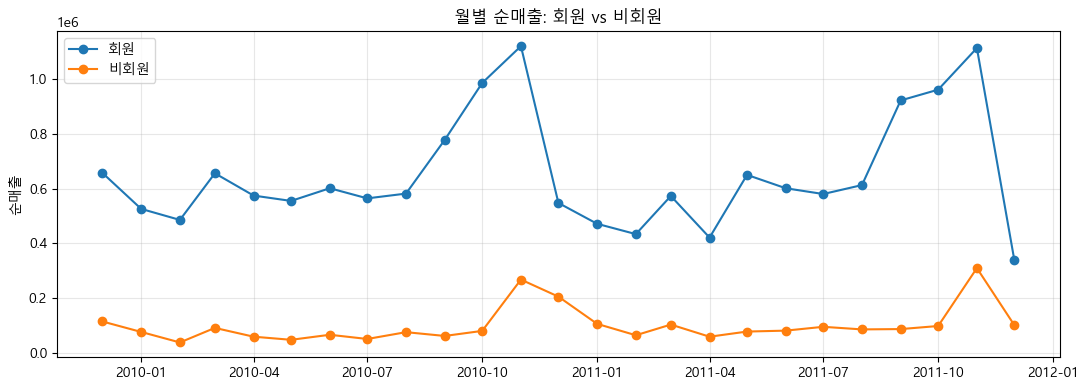

In [67]:
# --- 그래프 1: 월별 순매출 (회원 vs 비회원) ---
plt.figure(figsize=(11, 4))
plt.plot(m.index, m['회원'],   marker='o', label='회원')
plt.plot(m.index, m['비회원'], marker='o', label='비회원')
plt.title('월별 순매출: 회원 vs 비회원')
plt.ylabel('순매출')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

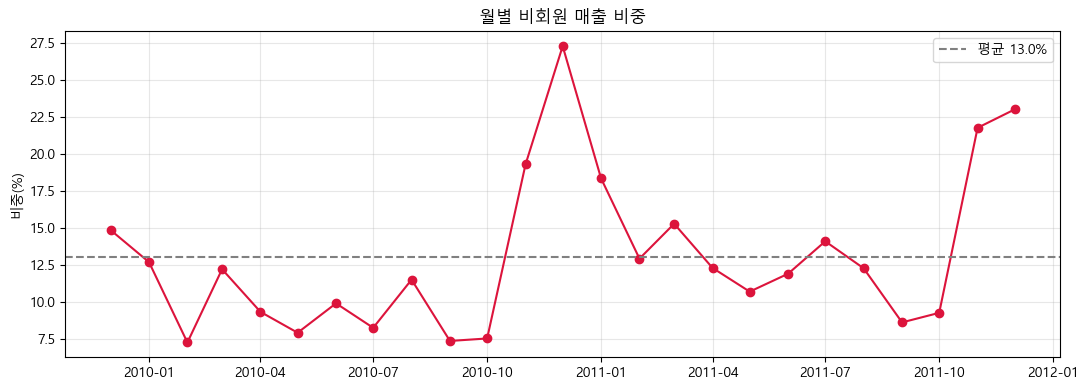

In [68]:
# --- 그래프 2: 월별 비회원 매출 비중 ---
plt.figure(figsize=(11, 4))
plt.plot(m.index, m['비회원비중%'], marker='o', color='crimson')
plt.axhline(m['비회원비중%'].mean(), ls='--', c='gray',
            label=f"평균 {m['비회원비중%'].mean():.1f}%")
plt.title('월별 비회원 매출 비중')
plt.ylabel('비중(%)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
#  비회원 제외 설명
비회원 거래는 전체 순매출의 13.6%(행 기준 22.2%)를 차지하며,
연말 성수기에는 평시 대비 2.5배 이상 매출 비중이 가파르게 증가한다.
이러한 피크는 현상은 총수요 관점에서는 유의미하나, RFM 기반 재구매 예측은 Customer ID가 없는 비회원 거래는 반복 구매를 정의할 수 없어 대상에서 제외하였다.